C:\Users\Yahya\AppData\Local\Temp\ipykernel_1908\2763553651.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed


Data Downloaded. Shape: (3522, 1)
Graph saved to: c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Machine Learning & Deep Learning in Finance\Generative Adversarial Networks (GANs) for Market Simulation\images\fig1_price_vs_returns.png


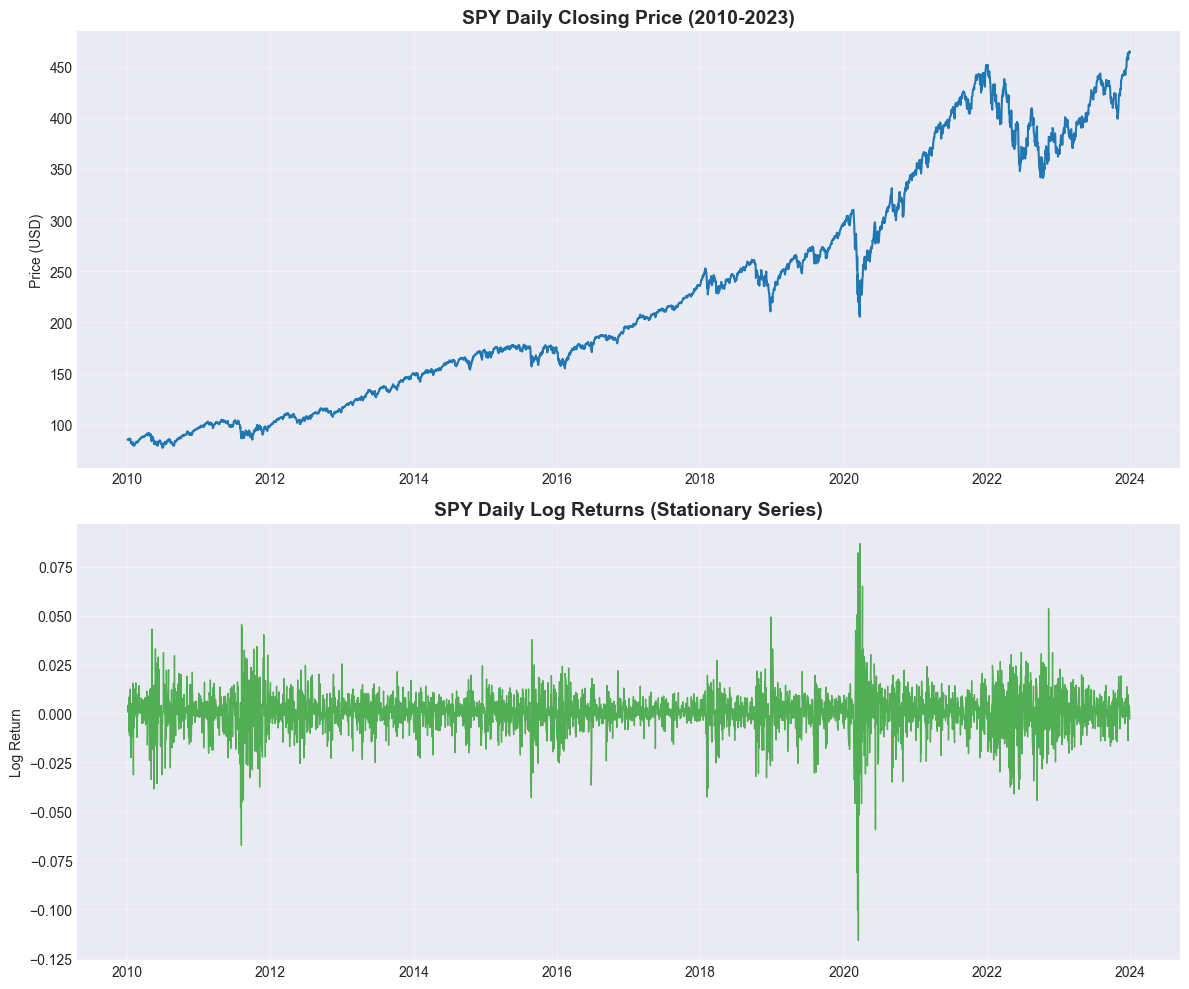

Scaler saved to: c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Machine Learning & Deep Learning in Finance\Generative Adversarial Networks (GANs) for Market Simulation\data\scaler.gz
----------------------------------------
Processing Complete.
Final Training Data Shape: (3461, 60, 1)
Data saved to: c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Machine Learning & Deep Learning in Finance\Generative Adversarial Networks (GANs) for Market Simulation\data\training_data.npy


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
import joblib

BASE_PATH = Path(r'c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Machine Learning & Deep Learning in Finance\Generative Adversarial Networks (GANs) for Market Simulation')
DATA_PATH = BASE_PATH / 'data'
IMAGE_PATH = BASE_PATH / 'images'
CODE_PATH = BASE_PATH / 'code'

# --- 2. Data Acquisition ---
# We use the S&P 500 ETF (SPY) as our proxy for the US Market.
# Source: Yahoo Finance (2010 - 2023)
TICKER = 'SPY'
START_DATE = '2010-01-01'
END_DATE = '2023-12-31'

print(f"Downloading {TICKER} data from {START_DATE} to {END_DATE}...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

# Handle cases where yfinance returns MultiIndex columns
if isinstance(df.columns, pd.MultiIndex):
    df = df.xs('Close', axis=1, level=0) if 'Close' in df.columns.get_level_values(0) else df
    # If the above fails or structure varies, simple fallback:
    if 'Close' in df.columns:
        df = df[['Close']]
    else:
        # Fallback for recent yfinance versions that might just return 'Adj Close' or 'Close' directly
        df = df.iloc[:, 0].to_frame(name='Close') 
else:
    df = df[['Close']]

df.columns = ['Close']
print(f"Data Downloaded. Shape: {df.shape}")

# --- 3. Feature Engineering: Log Returns ---
# Formula: R_t = ln(P_t / P_{t-1})
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()  # Remove the first NaN row

# --- 4. Visualizations ---
plt.style.use('seaborn-v0_8-darkgrid') 
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Plot A: Non-Stationary Price History
ax[0].plot(df.index, df['Close'], color='#1f77b4', linewidth=1.5)
ax[0].set_title(f'{TICKER} Daily Closing Price (2010-2023)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Price (USD)')
ax[0].grid(True, alpha=0.3)

# Plot B: Stationary Log Returns
ax[1].plot(df.index, df['Log_Ret'], color='#2ca02c', linewidth=1, alpha=0.8)
ax[1].set_title(f'{TICKER} Daily Log Returns (Stationary Series)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Log Return')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = IMAGE_PATH / 'fig1_price_vs_returns.png'
plt.savefig(save_path, dpi=300)
print(f"Graph saved to: {save_path}")
plt.show()

# --- 5. Data Normalization & Sequence Creation ---
# GANs require data scaled between -1 and 1 for the Tanh activation function.
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(df[['Log_Ret']].values)

# Save the scaler (Critical for inverse transforming later)
scaler_path = DATA_PATH / 'scaler.gz'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

# Create Rolling Window Sequences
# We feed the GAN 60 days of data, and it tries to learn the pattern.
SEQ_LEN = 60

def create_sequences(data, seq_len):
    sequences = []
    for i in range(len(data) - seq_len):
        seq = data[i : i + seq_len]
        sequences.append(seq)
    return np.array(sequences)

X_train = create_sequences(data_scaled, SEQ_LEN)

# Save processed data
data_save_path = DATA_PATH / 'training_data.npy'
np.save(data_save_path, X_train)

print("-" * 40)
print(f"Processing Complete.")
print(f"Final Training Data Shape: {X_train.shape}")
print(f"Data saved to: {data_save_path}")